In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow import keras
from tensorflow.keras import layers

In [2]:
csv_path = "data/sp500_5yr_with_sectors_weights.csv"

df = pd.read_csv(csv_path)

if "Weight" in df.columns:
    df = df.drop(columns=["Weight"])

df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values(["Symbol", "Date"]).reset_index(drop=True)

# df.head()

In [3]:
# time periods for splitting

TRAIN_START = pd.Timestamp("2021-03-22")
TRAIN_END   = pd.Timestamp("2024-03-20")

VAL_START   = pd.Timestamp("2024-03-21")
VAL_END     = pd.Timestamp("2025-03-20")

UNSEEN_START = pd.Timestamp("2025-03-21")
UNSEEN_END   = pd.Timestamp("2026-03-20")

In [4]:
# keep only stocks that have data in all 3 periods to avoid unseen stock issues

train_symbols = set(df.loc[(df["Date"] >= TRAIN_START) & (df["Date"] <= TRAIN_END), "Symbol"].unique())
val_symbols = set(df.loc[(df["Date"] >= VAL_START) & (df["Date"] <= VAL_END), "Symbol"].unique())
unseen_symbols = set(df.loc[(df["Date"] >= UNSEEN_START) & (df["Date"] <= UNSEEN_END), "Symbol"].unique())

common_symbols = sorted(train_symbols & val_symbols & unseen_symbols)

df = df[df["Symbol"].isin(common_symbols)].copy()
df = df.sort_values(["Symbol", "Date"]).reset_index(drop=True)

print("Common stocks:", df["Symbol"].nunique())

Common stocks: 499


In [5]:
# split into train/val/unseen

train_df = df[(df["Date"] >= TRAIN_START) & (df["Date"] <= TRAIN_END)].copy()
val_df = df[(df["Date"] >= VAL_START) & (df["Date"] <= VAL_END)].copy()
unseen_df = df[(df["Date"] >= UNSEEN_START) & (df["Date"] <= UNSEEN_END)].copy()

print("Train stocks:", train_df["Symbol"].nunique())
print("Val stocks:", val_df["Symbol"].nunique())
print("Unseen stocks:", unseen_df["Symbol"].nunique())

print("Train shape:", train_df.shape)
print("Val shape:", val_df.shape)
print("Unseen shape:", unseen_df.shape)

Train stocks: 499
Val stocks: 499
Unseen stocks: 499
Train shape: (374800, 9)
Val shape: (124750, 9)
Unseen shape: (125248, 9)


In [6]:
# export and remove unseen

unseen_df.to_csv("unseen_holdout_raw.csv", index=False)

df = pd.concat([train_df, val_df], axis=0).sort_values(["Symbol", "Date"]).reset_index(drop=True)

print("Model dataframe shape:", df.shape)
print("Train + Val Date range:", df["Date"].min(), "to", df["Date"].max())

Model dataframe shape: (499550, 9)
Train + Val Date range: 2021-03-22 00:00:00 to 2025-03-20 00:00:00


In [ ]:
# feature engineering function

def engineer_features(panel_df, horizon=21):
    panel_df = panel_df.copy()
    g = panel_df.groupby("Symbol")

    # returns
    panel_df["log_return_1d"] = g["Close"].transform(lambda x: np.log(x / x.shift(1)))

    # forward-looking target: realized volatility over t+1..t+horizon
    panel_df["target_fwd_vol_21d"] = g["log_return_1d"].transform(
        lambda x: x.rolling(21).std().shift(-21)
        )

    # close lags
    panel_df["close_lag_1d"] = g["Close"].shift(1)
    panel_df["close_lag_5d"] = g["Close"].shift(5)
    panel_df["close_lag_21d"] = g["Close"].shift(21)

    # daily vol proxy in price space
    panel_df["daily_volatility"] = g["Close"].transform(lambda x: x.diff().abs())
    panel_df["daily_volatility_lag_1d"] = g["daily_volatility"].shift(1)
    panel_df["daily_volatility_lag_5d"] = g["daily_volatility"].shift(5)

    # return-based rolling volatility feature (same unit family as target)
    panel_df["return_volatility_5d"] = g["log_return_1d"].transform(
        lambda x: x.rolling(5).std().shift(1)
    )

    # volume lags
    panel_df["volume_lag_1d"] = g["Volume"].shift(1)
    panel_df["volume_lag_5d"] = g["Volume"].shift(5)
    panel_df["volume_lag_21d"] = g["Volume"].shift(21)

    return panel_df


In [8]:
# apply feature engineering to dev set

df = engineer_features(df)

feature_cols = [
    "close_lag_1d",
    "close_lag_5d",
    "close_lag_21d",
    "daily_volatility_lag_1d",
    "daily_volatility_lag_5d",
    "return_volatility_5d",
    "volume_lag_1d",
    "volume_lag_5d",
    "volume_lag_21d",
]

target_col = "target_fwd_vol_21d"

df = df.dropna(subset=feature_cols + [target_col]).copy()

print(df.shape)
df.head()


(478592, 21)


,Date,Open,High,Low,Close,Volume,Symbol,Security,Sector,log_return_1d,...,close_lag_1d,close_lag_5d,close_lag_21d,daily_volatility,daily_volatility_lag_1d,daily_volatility_lag_5d,return_volatility_5d,volume_lag_1d,volume_lag_5d,volume_lag_21d
21,2021-04-21,128.617419,129.653087,127.785006,129.536942,1173900,A,Agilent Technologies,Health Care,0.010289,...,128.210922,127.736618,119.463020,1.326019,1.006622,0.967911,0.009642,1261200.0,1499300.0,1772900.0
22,2021-04-22,129.730502,131.114637,129.536920,130.214462,1732700,A,Agilent Technologies,Health Care,0.005217,...,129.536942,129.004578,117.887703,0.677521,1.326019,1.267960,0.009805,1173900.0,2121300.0,1338300.0
23,2021-04-23,130.253217,132.721405,130.185455,132.295517,1495200,A,Agilent Technologies,Health Care,0.015855,...,130.214462,130.262878,116.785934,2.081055,0.677521,1.258301,0.009165,1732700.0,4495400.0,1477500.0
24,2021-04-26,132.808491,133.408598,132.295479,132.934311,1287400,A,Agilent Technologies,Health Care,0.004817,...,132.295517,129.217545,117.810394,0.638794,2.081055,1.045334,0.010754,1495200.0,1071600.0,967300.0
25,2021-04-27,132.537460,133.031109,131.859918,132.101898,1752900,A,Agilent Technologies,Health Care,-0.006282,...,132.934311,128.210922,121.424896,0.832413,0.638794,1.006622,0.008775,1287400.0,1261200.0,1441900.0


In [43]:
df.feature_cols = feature_cols

/var/folders/sx/rlv33lyd2zs6vjp3khdjp3dc0000gn/T/ipykernel_19906/2979101694.py:1: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df.feature_cols = feature_cols


In [9]:
# create train/val sets for modeling

train_feat = df[(df["Date"] >= TRAIN_START) & (df["Date"] <= TRAIN_END)].copy()
val_feat = df[(df["Date"] >= VAL_START) & (df["Date"] <= VAL_END)].copy()

print(train_feat.shape, val_feat.shape)
print(train_feat["Symbol"].nunique(), val_feat["Symbol"].nunique())

(364321, 21) (114271, 21)
499 499


In [10]:
LOOKBACK = 21

def make_sequences(panel_df, feature_cols, target_col, lookback=21):
    X_list = []
    y_list = []
    meta_list = []

    for symbol, g in panel_df.groupby("Symbol"):
        g = g.sort_values("Date").reset_index(drop=True)

        X_values = g[feature_cols].values
        y_values = g[target_col].values
        dates = g["Date"].values

        for t in range(lookback - 1, len(g)):
            X_window = X_values[t - lookback + 1 : t + 1]
            y_target = y_values[t]

            X_list.append(X_window)
            y_list.append(y_target)
            meta_list.append({
                "Symbol": symbol,
                "Date": dates[t]
            })

    X = np.array(X_list, dtype=np.float32)
    y = np.array(y_list, dtype=np.float32)
    meta = pd.DataFrame(meta_list)

    return X, y, meta

In [11]:
# build sequences for train/val

X_train, y_train, meta_train = make_sequences(
    train_feat,
    feature_cols=feature_cols,
    target_col=target_col,
    lookback=LOOKBACK
)

X_val, y_val, meta_val = make_sequences(
    val_feat,
    feature_cols=feature_cols,
    target_col=target_col,
    lookback=LOOKBACK
)

print("Train:", X_train.shape, y_train.shape)
print("Val:", X_val.shape, y_val.shape)

Train: (354341, 21, 9) (354341,)
Val: (104291, 21, 9) (104291,)


In [12]:
# scale features and target using train stats

n_features = X_train.shape[2]

train_2d = X_train.reshape(-1, n_features)
feature_means = train_2d.mean(axis=0)
feature_stds = train_2d.std(axis=0) + 1e-8

X_train_scaled = (X_train - feature_means) / feature_stds
X_val_scaled = (X_val - feature_means) / feature_stds

y_mean = y_train.mean()
y_std = y_train.std() + 1e-8

y_train_scaled = (y_train - y_mean) / y_std
y_val_scaled = (y_val - y_mean) / y_std

In [13]:
# build model

keras.utils.set_random_seed(42)

model = keras.Sequential([
    layers.Input(shape=(LOOKBACK, len(feature_cols))),
    layers.LSTM(32),
    layers.Dense(16, activation="relu"),
    layers.Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         5,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,921 (23.13 KB)

 Trainable params: 5,921 (23.13 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# train

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )
]

history = model.fit(
    X_train_scaled,
    y_train_scaled,
    validation_data=(X_val_scaled, y_val_scaled),
    epochs=100,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
5537/5537 ━━━━━━━━━━━━━━━━━━━━ 34s 6ms/step - loss: 0.5374 - mae: 0.4997 - val_loss: 0.7186 - val_mae: 0.5378
Epoch 2/100
5537/5537 ━━━━━━━━━━━━━━━━━━━━ 31s 6ms/step - loss: 0.5103 - mae: 0.4896 - val_loss: 0.7177 - val_mae: 0.5370
Epoch 3/100
5537/5537 ━━━━━━━━━━━━━━━━━━━━ 28s 5ms/step - loss: 0.4990 - mae: 0.4856 - val_loss: 0.7150 - val_mae: 0.5356
Epoch 4/100
5537/5537 ━━━━━━━━━━━━━━━━━━━━ 27s 5ms/step - loss: 0.4900 - mae: 0.4825 - val_loss: 0.7183 - val_mae: 0.5333
Epoch 5/100
5537/5537 ━━━━━━━━━━━━━━━━━━━━ 26s 5ms/step - loss: 0.4821 - mae: 0.4798 - val_loss: 0.7218 - val_mae: 0.5359
Epoch 6/100
5537/5537 ━━━━━━━━━━━━━━━━━━━━ 27s 5ms/step - loss: 0.4742 - mae: 0.4771 - val_loss: 0.7227 - val_mae: 0.5358
Epoch 7/100
5537/5537 ━━━━━━━━━━━━━━━━━━━━ 32s 6ms/step - loss: 0.4676 - mae: 0.4747 - val_loss: 0.7262 - val_mae: 0.5348
Epoch 8/100
5537/5537 ━━━━━━━━━━━━━━━━━━━━ 30s 5ms/step - loss: 0.4592 - mae: 0.4720 - val_loss: 0.7225 - val_mae: 0.5359


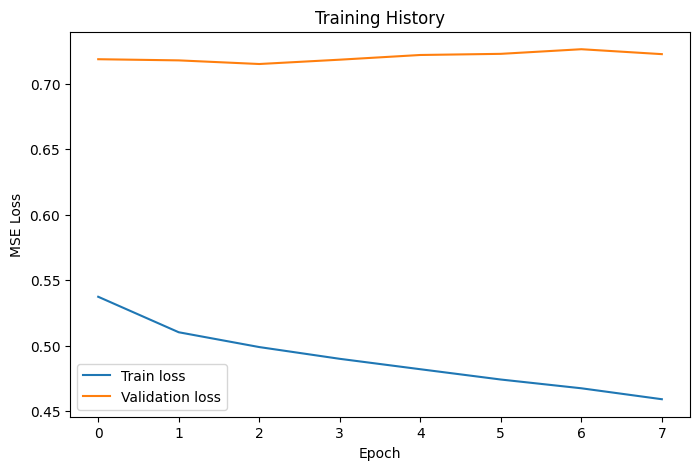

In [15]:
# plot training curve

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Train loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.title("Training History")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()

In [16]:
# load unseen

unseen_df = pd.read_csv("data/sp500_unseen.csv")

unseen_df["Date"] = pd.to_datetime(unseen_df["Date"])
unseen_df = unseen_df.sort_values(["Symbol", "Date"]).reset_index(drop=True)

print(unseen_df["Date"].min(), unseen_df["Date"].max())
print(unseen_df.shape)
print("Stocks:", unseen_df["Symbol"].nunique())

2025-03-21 00:00:00 2026-03-20 00:00:00
(125248, 10)
Stocks: 499


In [17]:
# build scoring dataframe

history_df = val_df.copy()

scoring_df = pd.concat([history_df, unseen_df], axis=0)
scoring_df = scoring_df.sort_values(["Symbol", "Date"]).reset_index(drop=True)

print(scoring_df["Date"].min(), scoring_df["Date"].max())
print(scoring_df.shape)

2024-03-21 00:00:00 2026-03-20 00:00:00
(249998, 10)


In [18]:
# feature engineer

scoring_df = engineer_features(scoring_df)
scoring_df = scoring_df.dropna(subset=feature_cols + [target_col]).copy()

print(scoring_df.shape)
print(scoring_df["Date"].min(), scoring_df["Date"].max())

(229040, 22)
2024-04-22 00:00:00 2026-02-19 00:00:00


In [19]:
# build sequence

X_score, y_score, meta_score = make_sequences(
    scoring_df,
    feature_cols=feature_cols,
    target_col=target_col,
    lookback=LOOKBACK
)

print("X_score:", X_score.shape)
print("meta range:", meta_score["Date"].min(), meta_score["Date"].max())

X_score: (219060, 21, 9)
meta range: 2024-05-20 00:00:00 2026-02-19 00:00:00


In [20]:
# extract unseen portion

unseen_mask = (
    (meta_score["Date"] >= UNSEEN_START) &
    (meta_score["Date"] <= UNSEEN_END)
)

print("Unseen rows:", unseen_mask.sum())

X_unseen = X_score[unseen_mask]
y_unseen = y_score[unseen_mask]
meta_unseen = meta_score[unseen_mask].reset_index(drop=True)

print("X_unseen:", X_unseen.shape)
print("y_unseen:", y_unseen.shape)
print("meta_unseen:", meta_unseen.shape)

Unseen rows: 114769
X_unseen: (114769, 21, 9)
y_unseen: (114769,)
meta_unseen: (114769, 2)


In [21]:
# scale and predict on unseen

if len(X_unseen) == 0:
    raise ValueError("X_unseen is empty — something still wrong")

X_unseen_scaled = (X_unseen - feature_means) / feature_stds

y_unseen_pred_scaled = model.predict(X_unseen_scaled).flatten()
y_unseen_pred = y_unseen_pred_scaled * y_std + y_mean

3587/3587 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step


In [22]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

unseen_rmse = np.sqrt(mean_squared_error(y_unseen, y_unseen_pred))
unseen_mae = mean_absolute_error(y_unseen, y_unseen_pred)
unseen_r2 = r2_score(y_unseen, y_unseen_pred)
unseen_corr = np.corrcoef(y_unseen, y_unseen_pred)[0, 1]

print("Unseen RMSE (LSTM):", unseen_rmse)
print("Unseen MAE (LSTM):", unseen_mae)
print("Unseen R^2 (LSTM):", unseen_r2)
print("Unseen Correlation (LSTM):", unseen_corr)


Unseen RMSE (LSTM): 0.008931687813480289
Unseen MAE (LSTM): 0.005918220151215792
Unseen R^2 (LSTM): 0.2519543170928955
Unseen Correlation (LSTM): 0.5109449767056561


In [23]:
# valid baselines on the same target scale

baseline_df = scoring_df[["Symbol", "Date", target_col]].copy()
baseline_df["baseline_persistence"] = baseline_df.groupby("Symbol")[target_col].shift(1)
baseline_df["baseline_rolling5"] = baseline_df.groupby("Symbol")[target_col].transform(
    lambda s: s.shift(1).rolling(5).mean()
)

baseline_unseen_df = meta_unseen.merge(
    baseline_df[["Symbol", "Date", "baseline_persistence", "baseline_rolling5"]],
    on=["Symbol", "Date"],
    how="left"
)

valid_mask = (
    baseline_unseen_df["baseline_persistence"].notna()
    & baseline_unseen_df["baseline_rolling5"].notna()
)

if valid_mask.sum() == 0:
    raise ValueError("No valid baseline rows after alignment")

# aligned eval arrays
keep_idx = valid_mask.values
y_eval = y_unseen[keep_idx]
y_pred_eval = y_unseen_pred[keep_idx]
meta_eval = meta_unseen.loc[keep_idx].reset_index(drop=True)

baseline_persistence_unseen = baseline_unseen_df.loc[valid_mask, "baseline_persistence"].to_numpy()
baseline_rolling5_unseen = baseline_unseen_df.loc[valid_mask, "baseline_rolling5"].to_numpy()

print("Eval rows after baseline alignment:", len(y_eval))


def metric_pack(y_true, y_pred):
    return {
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R^2": r2_score(y_true, y_pred),
        "Correlation": np.corrcoef(y_true, y_pred)[0, 1],
    }

lstm_metrics = metric_pack(y_eval, y_pred_eval)
persist_metrics = metric_pack(y_eval, baseline_persistence_unseen)
roll5_metrics = metric_pack(y_eval, baseline_rolling5_unseen)

print("Persistence Baseline RMSE:", persist_metrics["RMSE"])
print("Persistence Baseline MAE:", persist_metrics["MAE"])
print("Persistence Baseline R^2:", persist_metrics["R^2"])
print("Persistence Baseline Correlation:", persist_metrics["Correlation"])


Eval rows after baseline alignment: 114769
Persistence Baseline RMSE: 0.0021206656205318883
Persistence Baseline MAE: 0.0007565438786209916
Persistence Baseline R^2: 0.9578298216009533
Persistence Baseline Correlation: 0.9790906984535053


In [24]:
metrics_df = pd.DataFrame({
    "Metric": ["RMSE", "MAE", "R^2", "Correlation"],
    "LSTM": [lstm_metrics["RMSE"], lstm_metrics["MAE"], lstm_metrics["R^2"], lstm_metrics["Correlation"]],
    "Persistence_Baseline": [persist_metrics["RMSE"], persist_metrics["MAE"], persist_metrics["R^2"], persist_metrics["Correlation"]],
    "Rolling5_Baseline": [roll5_metrics["RMSE"], roll5_metrics["MAE"], roll5_metrics["R^2"], roll5_metrics["Correlation"]],
})

metrics_df


,Metric,LSTM,Persistence_Baseline,Rolling5_Baseline
0,RMSE,0.008932,0.002121,0.003320
1,MAE,0.005918,0.000757,0.001608
2,R^2,0.251954,0.957830,0.896615
3,Correlation,0.510945,0.979091,0.948539


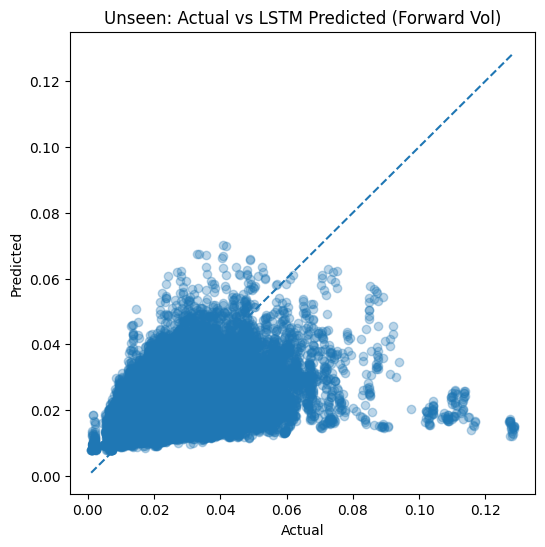

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.scatter(y_eval, y_pred_eval, alpha=0.3)

min_v = min(y_eval.min(), y_pred_eval.min())
max_v = max(y_eval.max(), y_pred_eval.max())
plt.plot([min_v, max_v], [min_v, max_v], linestyle="--")

plt.title("Unseen: Actual vs LSTM Predicted (Forward Vol)")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()


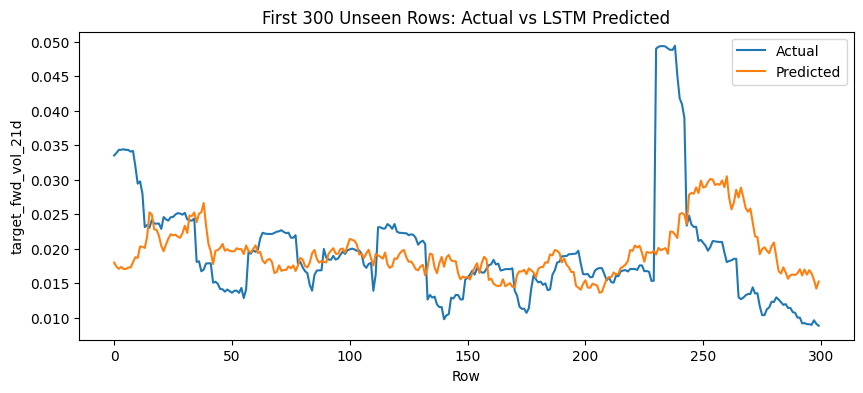

In [26]:
n_plot = min(300, len(y_eval))

plt.figure(figsize=(10, 4))
plt.plot(y_eval[:n_plot], label="Actual")
plt.plot(y_pred_eval[:n_plot], label="Predicted")
plt.title("First 300 Unseen Rows: Actual vs LSTM Predicted")
plt.xlabel("Row")
plt.ylabel(target_col)
plt.legend()
plt.show()


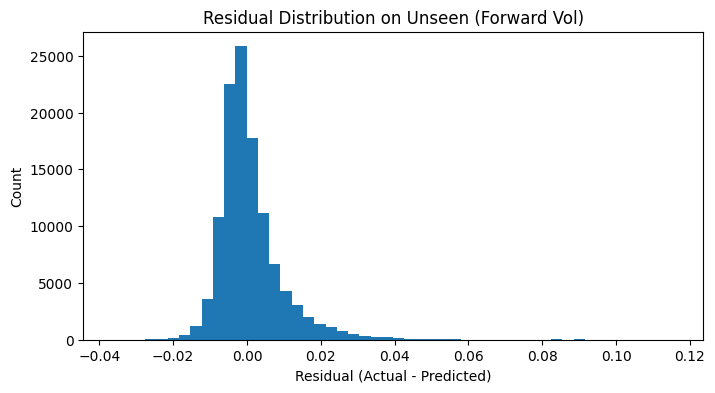

In [27]:
unseen_residuals = y_eval - y_pred_eval

plt.figure(figsize=(8, 4))
plt.hist(unseen_residuals, bins=50)
plt.title("Residual Distribution on Unseen (Forward Vol)")
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Count")
plt.show()


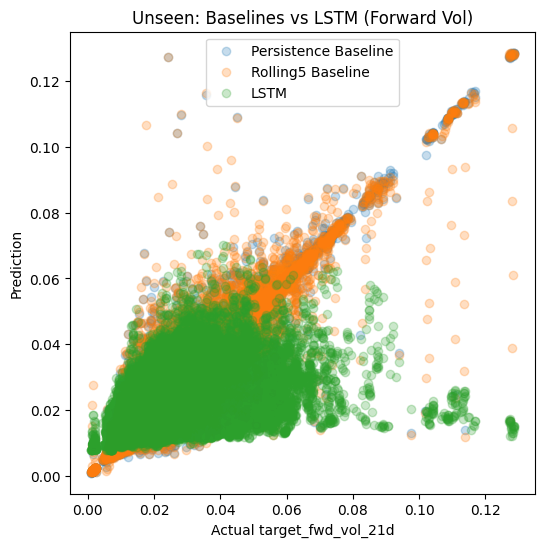

In [28]:
plt.figure(figsize=(6, 6))
plt.scatter(y_eval, baseline_persistence_unseen, alpha=0.25, label="Persistence Baseline")
plt.scatter(y_eval, baseline_rolling5_unseen, alpha=0.25, label="Rolling5 Baseline")
plt.scatter(y_eval, y_pred_eval, alpha=0.25, label="LSTM")
plt.title("Unseen: Baselines vs LSTM (Forward Vol)")
plt.xlabel(f"Actual {target_col}")
plt.ylabel("Prediction")
plt.legend()
plt.show()


In [29]:
# per stock

eval_df = meta_eval.copy()
eval_df["actual"] = y_eval
eval_df["predicted"] = y_pred_eval
eval_df["baseline_persistence_pred"] = baseline_persistence_unseen
eval_df["baseline_rolling5_pred"] = baseline_rolling5_unseen
eval_df["residual"] = eval_df["actual"] - eval_df["predicted"]

eval_df.head()


,Symbol,Date,actual,predicted,baseline_persistence_pred,baseline_rolling5_pred,residual
0,A,2025-03-21,0.033507,0.017992,0.032785,0.032766,0.015516
1,A,2025-03-24,0.033881,0.017390,0.033507,0.032885,0.016491
2,A,2025-03-25,0.034328,0.017085,0.033881,0.033105,0.017243
3,A,2025-03-26,0.034329,0.017365,0.034328,0.033438,0.016964
4,A,2025-03-27,0.034411,0.017065,0.034329,0.033766,0.017346


In [30]:
def stock_metrics(group):
    y_true = group["actual"].values
    y_pred = group["predicted"].values
    y_base = group["baseline_persistence_pred"].values

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    base_rmse = np.sqrt(mean_squared_error(y_true, y_base))
    base_mae = mean_absolute_error(y_true, y_base)

    if len(y_true) > 1 and np.std(y_true) > 0 and np.std(y_pred) > 0:
        corr = np.corrcoef(y_true, y_pred)[0, 1]
    else:
        corr = np.nan

    if len(y_true) > 1 and np.std(y_true) > 0:
        r2 = r2_score(y_true, y_pred)
    else:
        r2 = np.nan

    return pd.Series({
        "n_obs": len(group),
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
        "corr": corr,
        "persistence_rmse": base_rmse,
        "persistence_mae": base_mae,
        "rmse_improvement_vs_persistence": base_rmse - rmse,
        "mae_improvement_vs_persistence": base_mae - mae
    })

per_stock_results = eval_df.groupby("Symbol").apply(stock_metrics).reset_index()
per_stock_results.head()


/var/folders/sx/rlv33lyd2zs6vjp3khdjp3dc0000gn/T/ipykernel_19906/1004184517.py:33: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  per_stock_results = eval_df.groupby("Symbol").apply(stock_metrics).reset_index()


,Symbol,n_obs,rmse,mae,r2,corr,persistence_rmse,persistence_mae,rmse_improvement_vs_persistence,mae_improvement_vs_persistence
0,A,230.0,0.005036,0.003665,-0.032195,0.215156,0.001302,0.000680,-0.003734,-0.002985
1,AAPL,230.0,0.008446,0.006239,0.046697,0.340781,0.001488,0.000652,-0.006958,-0.005587
2,ABBV,230.0,0.007072,0.005407,-1.377307,-0.228597,0.001124,0.000632,-0.005948,-0.004775
3,ABNB,230.0,0.007060,0.005924,0.075810,0.388908,0.001625,0.000736,-0.005435,-0.005188
4,ABT,230.0,0.005840,0.004108,-0.264233,-0.189270,0.001858,0.000592,-0.003982,-0.003516


In [31]:
per_stock_results[["rmse", "mae", "r2", "corr"]].describe()

,rmse,mae,r2,corr
count,499.000000,499.000000,499.000000,499.000000
mean,0.007953,0.005918,-0.371512,0.079449
std,0.004071,0.002549,0.506015,0.253348
min,0.002914,0.002270,-4.012990,-0.600962
25%,0.005285,0.004214,-0.492541,-0.101144
50%,0.007029,0.005242,-0.267641,0.085866
75%,0.009365,0.006890,-0.106871,0.256463
max,0.037071,0.020006,0.409766,0.755796


In [32]:
print("Stocks beating persistence baseline on RMSE:",
      (per_stock_results["rmse_improvement_vs_persistence"] > 0).sum())

print("Stocks beating persistence baseline on MAE:",
      (per_stock_results["mae_improvement_vs_persistence"] > 0).sum())

print("Median per-stock correlation:",
      per_stock_results["corr"].median())

print("Median per-stock R^2:",
      per_stock_results["r2"].median())


Stocks beating persistence baseline on RMSE: 0
Stocks beating persistence baseline on MAE: 0
Median per-stock correlation: 0.0858660924561284
Median per-stock R^2: -0.2676410675048828


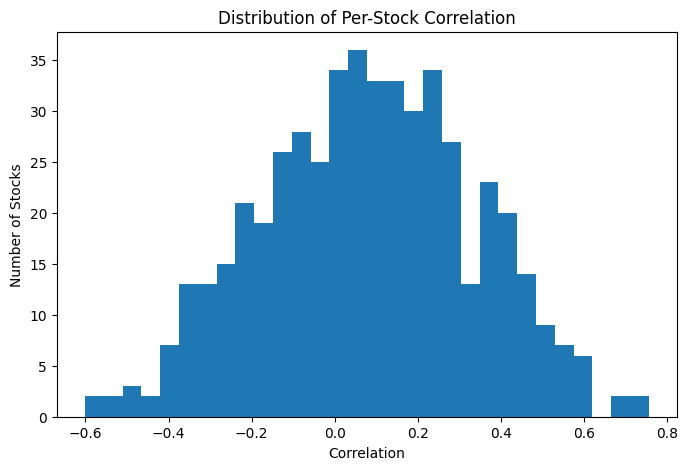

In [33]:
plt.figure(figsize=(8, 5))
plt.hist(per_stock_results["corr"].dropna(), bins=30)
plt.title("Distribution of Per-Stock Correlation")
plt.xlabel("Correlation")
plt.ylabel("Number of Stocks")
plt.show()

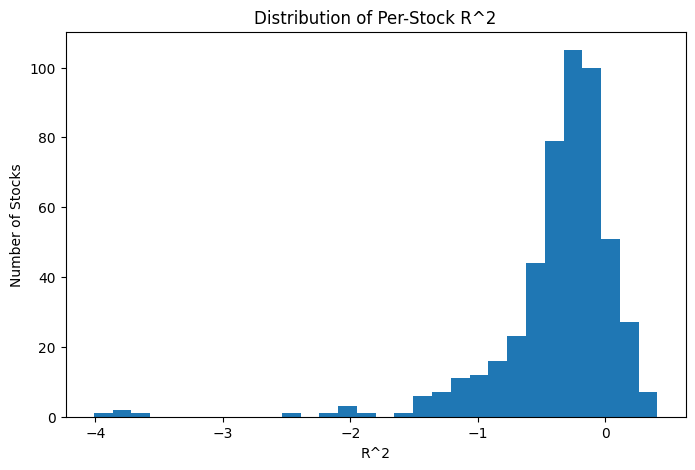

In [34]:
plt.figure(figsize=(8, 5))
plt.hist(per_stock_results["r2"].dropna(), bins=30)
plt.title("Distribution of Per-Stock R^2")
plt.xlabel("R^2")
plt.ylabel("Number of Stocks")
plt.show()

In [35]:
best_stocks = per_stock_results.sort_values("corr", ascending=False).head(10)
worst_stocks = per_stock_results.sort_values("corr", ascending=True).head(10)

print("Best stocks by correlation")
display(best_stocks)

print("Worst stocks by correlation")
display(worst_stocks)

Best stocks by correlation


,Symbol,n_obs,rmse,mae,r2,corr,persistence_rmse,persistence_mae,rmse_improvement_vs_persistence,mae_improvement_vs_persistence
388,REGN,230.0,0.008318,0.005759,0.380109,0.755796,0.003006,0.000919,-0.005312,-0.004841
225,HOLX,230.0,0.008261,0.007101,0.340156,0.715637,0.001908,0.000519,-0.006353,-0.006582
328,NEE,230.0,0.003390,0.002728,0.409766,0.697154,0.001182,0.000607,-0.002208,-0.002121
155,ED,230.0,0.003473,0.002973,-0.929987,0.677508,0.000577,0.000380,-0.002895,-0.002593
108,COST,230.0,0.003081,0.002419,-0.095601,0.619434,0.000859,0.000464,-0.002222,-0.001955
478,WDC,230.0,0.013671,0.011003,0.241444,0.602603,0.002667,0.001379,-0.011004,-0.009624
152,EA,230.0,0.007922,0.006466,0.321292,0.599787,0.002200,0.000601,-0.005722,-0.005866
278,LHX,230.0,0.003804,0.003183,0.327926,0.587936,0.000932,0.000493,-0.002872,-0.002690
383,PWR,230.0,0.005015,0.003985,0.321869,0.586653,0.001426,0.000762,-0.003589,-0.003223
393,ROK,230.0,0.005917,0.004500,0.324431,0.577450,0.001508,0.000663,-0.004409,-0.003837


Worst stocks by correlation


,Symbol,n_obs,rmse,mae,r2,corr,persistence_rmse,persistence_mae,rmse_improvement_vs_persistence,mae_improvement_vs_persistence
287,LUV,230.0,0.013664,0.010536,-0.696694,-0.600962,0.002871,0.001116,-0.010793,-0.009420
310,MOH,230.0,0.024242,0.018387,-0.777459,-0.571439,0.005718,0.001719,-0.018524,-0.016668
41,ARE,230.0,0.012509,0.008288,-0.471099,-0.526534,0.003015,0.001059,-0.009494,-0.007229
235,HUM,230.0,0.015826,0.012067,-1.199789,-0.523647,0.003809,0.001313,-0.012017,-0.010754
142,DOC,230.0,0.005159,0.004713,-1.367793,-0.477606,0.001123,0.000567,-0.004037,-0.004146
54,BAX,230.0,0.016479,0.011409,-0.387820,-0.476320,0.004649,0.001320,-0.011830,-0.010089
160,ELV,230.0,0.012719,0.009576,-0.766724,-0.474633,0.002907,0.001092,-0.009812,-0.008484
468,VRSN,230.0,0.007582,0.006528,-0.412639,-0.444668,0.001675,0.000695,-0.005907,-0.005833
370,PM,230.0,0.004865,0.003751,-0.679198,-0.433318,0.001359,0.000590,-0.003507,-0.003161
298,MCK,230.0,0.008424,0.005370,-0.250699,-0.411855,0.002261,0.000749,-0.006163,-0.004621


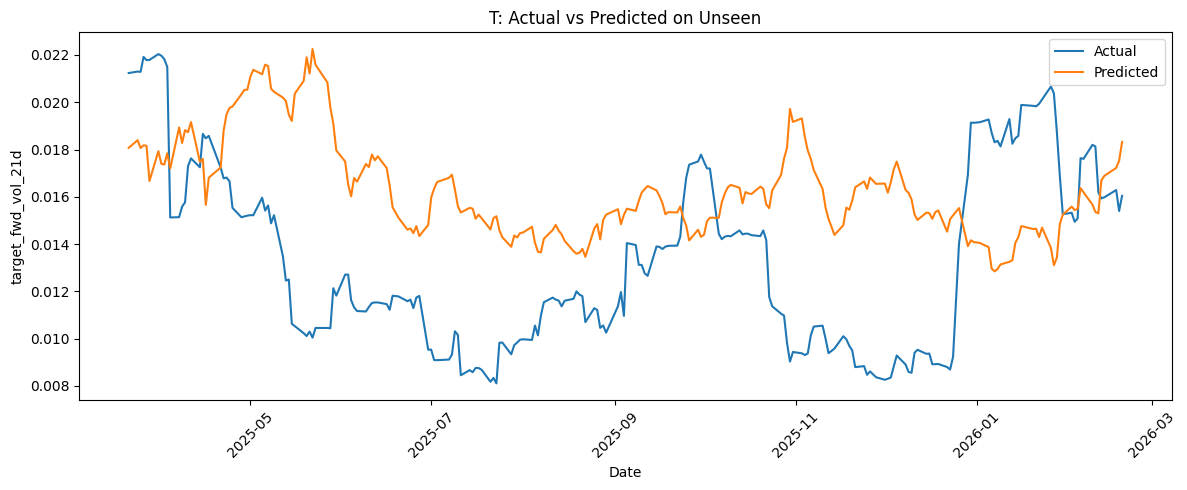

In [36]:
symbol_to_plot = "T"

stock_df = eval_df[eval_df["Symbol"] == symbol_to_plot].sort_values("Date")

plt.figure(figsize=(12, 5))
plt.plot(stock_df["Date"], stock_df["actual"], label="Actual")
plt.plot(stock_df["Date"], stock_df["predicted"], label="Predicted")
plt.title(f"{symbol_to_plot}: Actual vs Predicted on Unseen")
plt.xlabel("Date")
plt.ylabel(target_col)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


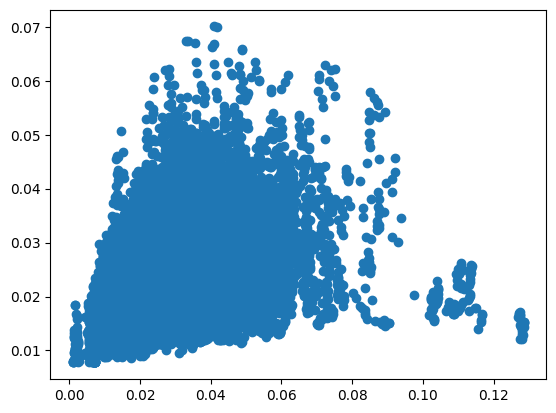

In [37]:
plt.scatter(y_unseen, y_unseen_pred)

In [38]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd

base_rmse = np.sqrt(mean_squared_error(y_eval, y_pred_eval))
base_mae = mean_absolute_error(y_eval, y_pred_eval)
base_r2 = r2_score(y_eval, y_pred_eval)

print("Base unseen RMSE (LSTM, aligned eval):", base_rmse)
print("Base unseen MAE (LSTM, aligned eval):", base_mae)
print("Base unseen R^2 (LSTM, aligned eval):", base_r2)


Base unseen RMSE (LSTM, aligned eval): 0.008931687813480289
Base unseen MAE (LSTM, aligned eval): 0.005918220151215792
Base unseen R^2 (LSTM, aligned eval): 0.2519543170928955


In [39]:
def permutation_importance_lstm(model, X_scaled, y_true, feature_cols, y_mean, y_std, n_repeats=5, random_state=42):
    rng = np.random.default_rng(random_state)
    results = []

    # baseline predictions
    y_pred_scaled = model.predict(X_scaled, verbose=0).flatten()
    y_pred = y_pred_scaled * y_std + y_mean

    baseline_rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    baseline_mae = mean_absolute_error(y_true, y_pred)
    baseline_r2 = r2_score(y_true, y_pred)

    n_samples, lookback, n_features = X_scaled.shape

    for j, feature in enumerate(feature_cols):
        rmse_scores = []
        mae_scores = []
        r2_scores = []

        for _ in range(n_repeats):
            X_perm = X_scaled.copy()

            # shuffle this feature across samples, keeping time order inside each sample
            shuffled_idx = rng.permutation(n_samples)
            X_perm[:, :, j] = X_perm[shuffled_idx, :, j]

            y_perm_scaled = model.predict(X_perm, verbose=0).flatten()
            y_perm = y_perm_scaled * y_std + y_mean

            rmse_scores.append(np.sqrt(mean_squared_error(y_true, y_perm)))
            mae_scores.append(mean_absolute_error(y_true, y_perm))
            r2_scores.append(r2_score(y_true, y_perm))

        results.append({
            "feature": feature,
            "baseline_rmse": baseline_rmse,
            "perm_rmse_mean": np.mean(rmse_scores),
            "rmse_increase": np.mean(rmse_scores) - baseline_rmse,
            "baseline_mae": baseline_mae,
            "perm_mae_mean": np.mean(mae_scores),
            "mae_increase": np.mean(mae_scores) - baseline_mae,
            "baseline_r2": baseline_r2,
            "perm_r2_mean": np.mean(r2_scores),
            "r2_drop": baseline_r2 - np.mean(r2_scores),
        })

    return pd.DataFrame(results).sort_values("rmse_increase", ascending=False).reset_index(drop=True)

In [40]:
perm_importance_df = permutation_importance_lstm(
    model=model,
    X_scaled=X_unseen_scaled,
    y_true=y_unseen,
    feature_cols=feature_cols,
    y_mean=y_mean,
    y_std=y_std,
    n_repeats=5,
    random_state=42
)

perm_importance_df

,feature,baseline_rmse,perm_rmse_mean,rmse_increase,baseline_mae,perm_mae_mean,mae_increase,baseline_r2,perm_r2_mean,r2_drop
0,daily_volatility_lag_5d,0.008932,0.014717,0.005785,0.005918,0.010699,0.004780,0.251954,-1.030861,1.282816
1,close_lag_1d,0.008932,0.014345,0.005413,0.005918,0.009960,0.004041,0.251954,-0.929446,1.181400
2,daily_volatility_lag_1d,0.008932,0.012442,0.003510,0.005918,0.009007,0.003089,0.251954,-0.451529,0.703483
3,volume_lag_21d,0.008932,0.010004,0.001072,0.005918,0.006852,0.000934,0.251954,0.061539,0.190416
4,return_volatility_5d,0.008932,0.009838,0.000906,0.005918,0.006879,0.000960,0.251954,0.092475,0.159479
5,close_lag_21d,0.008932,0.009570,0.000639,0.005918,0.006317,0.000399,0.251954,0.141168,0.110786
6,close_lag_5d,0.008932,0.009457,0.000525,0.005918,0.006355,0.000437,0.251954,0.161458,0.090496
7,volume_lag_1d,0.008932,0.009244,0.000313,0.005918,0.006231,0.000313,0.251954,0.198652,0.053302
8,volume_lag_5d,0.008932,0.009095,0.000163,0.005918,0.006032,0.000114,0.251954,0.224323,0.027631


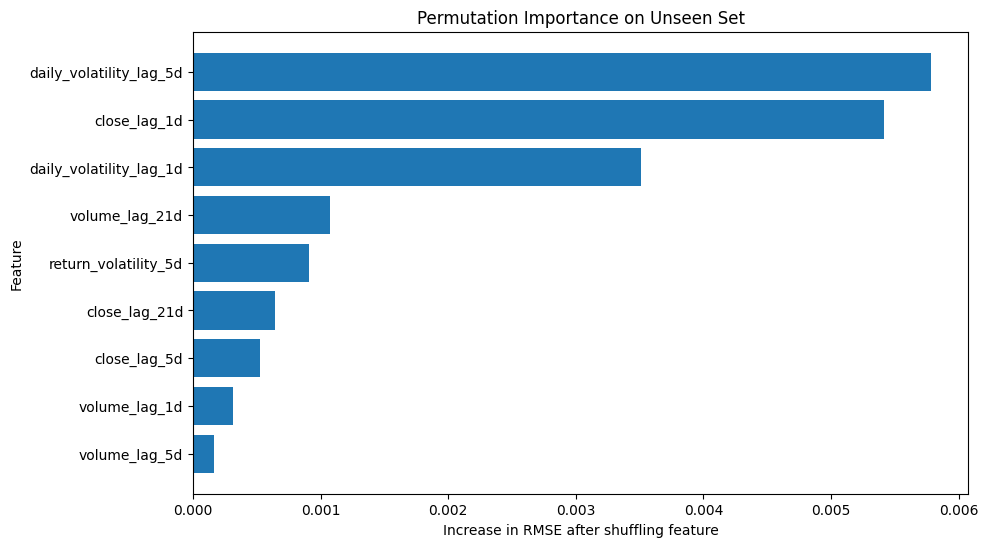

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(perm_importance_df["feature"], perm_importance_df["rmse_increase"])
plt.gca().invert_yaxis()
plt.title("Permutation Importance on Unseen Set")
plt.xlabel("Increase in RMSE after shuffling feature")
plt.ylabel("Feature")
plt.show()

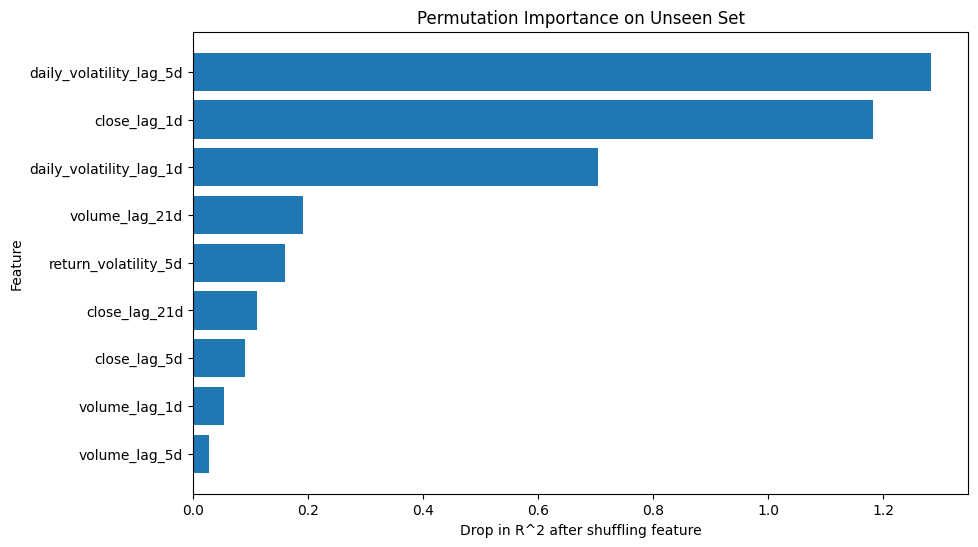

In [42]:
plt.figure(figsize=(10, 6))
plt.barh(perm_importance_df["feature"], perm_importance_df["r2_drop"])
plt.gca().invert_yaxis()
plt.title("Permutation Importance on Unseen Set")
plt.xlabel("Drop in R^2 after shuffling feature")
plt.ylabel("Feature")
plt.show()